### DoRA re-implementation on Llama 3.1 8B Base/Instruct

Clean end-to-end Colab pipeline using the project custom `DoRALinear` / `inject_dora` wrapper.

Cells:
1. Write scripts
2. Load secrets and env config
3. Model and DoRA adapter setup
4. Training cell
5. Eval cell


### Mount on Drive and Config

In [ ]:
# 2) Load secrets and env config
%pip install -q transformers accelerate sentencepiece safetensors tqdm

from google.colab import drive, userdata
drive.mount('/content/drive')

import os
import sys
from pathlib import Path

try:
    token = userdata.get('Dora_key') or userdata.get('HF_TOKEN')
    if token:
        os.environ['HF_TOKEN'] = token
except Exception:
    pass

SRC_DIR = "/content/drive/MyDrive/DoRA_instruct"
sys.path.insert(0, SRC_DIR)

DRIVE_ROOT = SRC_DIR
DATA_DIR = f"{DRIVE_ROOT}/data"
EVAL_DIR = f"{DRIVE_ROOT}/eval_data"
CKPT_DIR = f"{DRIVE_ROOT}/checkpoints_custom_instruct"
LOG_DIR = f"{DRIVE_ROOT}/logs_custom_instruct"
MODEL_CACHE = "/content/model_cache"

for d in [DATA_DIR, EVAL_DIR, CKPT_DIR, LOG_DIR, MODEL_CACHE]:
    Path(d).mkdir(parents=True, exist_ok=True)

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct" #"meta-llama/Llama-3.1-8B"
TRAIN_PATH = f"{DATA_DIR}/commonsense_170k.json"

# Based on paper config
RANK = 32 #8, 16
ALPHA = 64.0 #16.0, 32.0
ADAPT_MLP = True
EPOCHS = 3
LR = 1e-6 #1e-5
BATCH_SIZE = 32 #16, 64
MAX_LENGTH = 256 #64
GRAD_ACCUM_STEPS = 1
WARMUP_STEPS = 100
SEED = 42

print("MODEL_ID:", MODEL_ID)
print("TRAIN_PATH:", TRAIN_PATH)
print("CKPT_DIR:", CKPT_DIR)
print("SRC_DIR:", SRC_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL_ID: meta-llama/Llama-3.1-8B-Instruct
TRAIN_PATH: /content/drive/MyDrive/DoRA_instruct/data/train.json
CKPT_DIR: /content/drive/MyDrive/DoRA_instruct/checkpoints_custom_instruct
SRC_DIR: /content/drive/MyDrive/DoRA_instruct


### Run to write scripts on Drive once mounted

In [ ]:
# @title
# 1) Write scripts
# Custom DoRA implementation. No PEFT LoraConfig/use_dora is used.
# Scripts are written to the local Colab runtime; checkpoints/data remain on Drive.

from pathlib import Path

SRC_DIR = "/content/drive/MyDrive/DoRA_instruct"
Path(SRC_DIR).mkdir(parents=True, exist_ok=True)

Path(f"{SRC_DIR}/data.py").write_text(r'''
import json
from pathlib import Path
from typing import Any

import torch
from torch.utils.data import Dataset

PROMPT_WITH_INPUT = (
    "Below is an instruction that describes a task, paired with an input "
    "that provides further context. Write a response that appropriately "
    "completes the request.\n\n"
    "### Instruction:\n{instruction}\n\n"
    "### Input:\n{input}\n\n"
    "### Response:\n{output}"
)
PROMPT_NO_INPUT = (
    "Below is an instruction that describes a task. Write a response that "
    "appropriately completes the request.\n\n"
    "### Instruction:\n{instruction}\n\n"
    "### Response:\n{output}"
)

def load_dataset_json(path: str | Path) -> list[dict[str, Any]]:
    with Path(path).open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(f"expected list in {path}")
    return data

def format_example(sample: dict[str, Any]) -> str:
    if str(sample.get("input", "")).strip():
        return PROMPT_WITH_INPUT.format(
            instruction=sample["instruction"],
            input=sample["input"],
            output=sample["output"],
        )
    return PROMPT_NO_INPUT.format(instruction=sample["instruction"], output=sample["output"])

def format_prompt(sample: dict[str, Any]) -> str:
    return format_example({**sample, "output": ""})

class CommonsenseDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=512):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        prompt_ids = self.tokenizer(
            format_prompt(sample), add_special_tokens=True, truncation=False, return_attention_mask=False
        )["input_ids"]
        response_ids = self.tokenizer(
            str(sample["output"]), add_special_tokens=False, truncation=False, return_attention_mask=False
        )["input_ids"]
        if self.tokenizer.eos_token_id is not None:
            response_ids = response_ids + [self.tokenizer.eos_token_id]
        if len(response_ids) >= self.max_length:
            prompt_ids = []
            response_ids = response_ids[: self.max_length]
        else:
            prompt_ids = prompt_ids[-(self.max_length - len(response_ids)):]
        input_ids = prompt_ids + response_ids
        labels = [-100] * len(prompt_ids) + response_ids.copy()
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.ones(len(input_ids), dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

def _left_pad_1d(sequences, padding_value):
    max_length = max(seq.size(0) for seq in sequences)
    padded = sequences[0].new_full((len(sequences), max_length), padding_value)
    for row, seq in enumerate(sequences):
        padded[row, -seq.size(0):] = seq
    return padded

def collate_fn(batch):
    return {
        "input_ids": _left_pad_1d([x["input_ids"] for x in batch], 0),
        "attention_mask": _left_pad_1d([x["attention_mask"] for x in batch], 0),
        "labels": _left_pad_1d([x["labels"] for x in batch], -100),
    }
''', encoding="utf-8")

Path(f"{SRC_DIR}/dora.py").write_text(r'''
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

ADAPTER_KEYWORDS = ("lora_A", "lora_B", "magnitude")

class DoRALinear(nn.Module):
    """Custom DoRA adapter around a frozen nn.Linear layer.

    W' = m * normalize(W + scale * B @ A), with row-wise normalization.
    """

    def __init__(self, base: nn.Linear, r: int = 16, alpha: float = 32.0):
        super().__init__()
        if not isinstance(base, nn.Linear):
            raise TypeError("DoRALinear expects nn.Linear")
        self.base = base
        self.r = int(r)
        self.alpha = float(alpha)
        self.scaling = self.alpha / max(1, self.r)
        self.in_features = base.in_features
        self.out_features = base.out_features

        for p in self.base.parameters():
            p.requires_grad = False

        dtype = base.weight.dtype
        device = base.weight.device
        a = torch.empty((self.r, self.in_features), dtype=torch.float32, device=device)
        nn.init.kaiming_uniform_(a, a=math.sqrt(5))
        self.lora_A = nn.Parameter(a.to(dtype=dtype))
        self.lora_B = nn.Parameter(torch.zeros((self.out_features, self.r), dtype=dtype, device=device))
        self.magnitude = nn.Parameter(base.weight.detach().norm(dim=1).clone().to(dtype=dtype, device=device))

    def adapted_weight(self):
        delta = (self.lora_B @ self.lora_A) * self.scaling
        weight = self.base.weight + delta.to(dtype=self.base.weight.dtype)
        direction = F.normalize(weight.float(), p=2, dim=1).to(dtype=weight.dtype)
        return direction * self.magnitude[:, None]

    def forward(self, x):
        return F.linear(x, self.adapted_weight(), self.base.bias)

def dora_param_count(model: nn.Module) -> dict[str, float]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "total": total,
        "trainable": trainable,
        "frozen": total - trainable,
        "trainable_pct": round(100 * trainable / total, 4) if total else 0.0,
    }

def adapter_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    return {
        k: v.detach().cpu()
        for k, v in model.state_dict().items()
        if any(key in k for key in ADAPTER_KEYWORDS)
    }
''', encoding="utf-8")

Path(f"{SRC_DIR}/inject.py").write_text(r'''
from typing import List

import torch.nn as nn

from dora import DoRALinear, dora_param_count

ADAPTER_KEYWORDS = ("lora_A", "lora_B", "magnitude")

def _name_matches(name: str, target_names: List[str]) -> bool:
    return any(name == pattern or name.endswith(f".{pattern}") for pattern in target_names)

def _set_submodule(model: nn.Module, key: str, new_module: nn.Module):
    parent = model
    parts = key.split(".")
    for part in parts[:-1]:
        parent = getattr(parent, part)
    setattr(parent, parts[-1], new_module)

def inject_dora(
    model: nn.Module,
    target_names: List[str],
    r: int = 16,
    lora_alpha: float = 32.0,
    dropout: float = 0.0,
    use_llama_mha: bool = False,
    adapt_mlp: bool = True,
) -> nn.Module:
    # Keep the old function signature. Instead of replacing full attention,
    # this clean version wraps the target Linear projections directly.
    if use_llama_mha:
        target_names = ["q_proj", "k_proj", "v_proj", "o_proj"]
        if adapt_mlp:
            target_names += ["up_proj", "down_proj"]

    replaced = []
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear) and _name_matches(name, target_names):
            _set_submodule(model, name, DoRALinear(module, r=r, alpha=lora_alpha))
            replaced.append(name)
    if not replaced:
        raise ValueError(f"No nn.Linear modules matched {target_names}")
    print(f"[inject_dora] Replaced {len(replaced)} layers")
    for name in replaced[:20]:
        print("  -", name)
    if len(replaced) > 20:
        print(f"  ... {len(replaced) - 20} more")
    return model

def get_trainable_params(model: nn.Module):
    return [(n, p) for n, p in model.named_parameters() if p.requires_grad and any(k in n for k in ADAPTER_KEYWORDS)]

def print_trainable_params(model: nn.Module):
    counts = dora_param_count(model)
    print(
        f"Trainable params: {counts['trainable']:,} / {counts['total']:,} "
        f"({counts['trainable_pct']}%) | Frozen: {counts['frozen']:,}"
    )
''', encoding="utf-8")

Path(f"{SRC_DIR}/train.py").write_text(r'''
import argparse
import json
import random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, get_linear_schedule_with_warmup

from data import CommonsenseDataset, collate_fn, load_dataset_json
from dora import adapter_state_dict
from inject import get_trainable_params, inject_dora, print_trainable_params

DTYPE = {"float32": torch.float32, "float16": torch.float16, "bfloat16": torch.bfloat16}

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--model_name", default="meta-llama/Llama-3.1-8B-Instruct")
    p.add_argument("--data_path", required=True)
    p.add_argument("--output_dir", required=True)
    p.add_argument("--r", type=int, default=16)
    p.add_argument("--alpha", type=float, default=32.0)
    p.add_argument("--epochs", type=int, default=1)
    p.add_argument("--lr", type=float, default=2e-5)
    p.add_argument("--batch_size", type=int, default=16)
    p.add_argument("--grad_accum_steps", type=int, default=1)
    p.add_argument("--max_length", type=int, default=512)
    p.add_argument("--warmup_steps", type=int, default=100)
    p.add_argument("--weight_decay", type=float, default=0.01)
    p.add_argument("--max_grad_norm", type=float, default=1.0)
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--dtype", choices=list(DTYPE), default="bfloat16")
    p.add_argument("--no_adapt_mlp", action="store_true")
    return p.parse_args()

def main():
    args = parse_args()
    random.seed(args.seed)
    np.random.seed(args.seed)
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
    Path(args.output_dir).mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(args.model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    model = AutoModelForCausalLM.from_pretrained(args.model_name, torch_dtype=DTYPE[args.dtype], device_map="cuda")
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    for p in model.parameters():
        p.requires_grad = False

    model = inject_dora(
        model,
        target_names=["q_proj", "k_proj", "v_proj", "o_proj"],
        r=args.r,
        lora_alpha=args.alpha,
        use_llama_mha=True,
        adapt_mlp=not args.no_adapt_mlp,
    )
    print_trainable_params(model)

    samples = load_dataset_json(args.data_path)
    dataset = CommonsenseDataset(samples, tokenizer, max_length=args.max_length)
    generator = torch.Generator().manual_seed(args.seed)
    loader = DataLoader(dataset, batch_size=args.batch_size, shuffle=True, generator=generator, collate_fn=collate_fn)

    trainable = [p for _, p in get_trainable_params(model)]
    optimizer = torch.optim.AdamW(trainable, lr=args.lr, weight_decay=args.weight_decay)
    total_steps = max(1, (len(loader) // args.grad_accum_steps) * args.epochs)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=args.warmup_steps, num_training_steps=total_steps)

    meta = vars(args) | {"adapter_format": "custom_dora_pt", "target_modules": ["q/k/v/o", "up/down if adapt_mlp"]}
    Path(args.output_dir, "adapter_config.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

    global_step = 0
    device = next(model.parameters()).device
    for epoch in range(1, args.epochs + 1):
        model.train()
        running = 0.0
        optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(loader, desc=f"epoch {epoch}")
        for micro_step, batch in enumerate(pbar, start=1):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss / args.grad_accum_steps
            loss.backward()
            running += outputs.loss.item()
            if micro_step % args.grad_accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(trainable, args.max_grad_norm)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1
            if micro_step % 10 == 0:
                pbar.set_postfix(loss=f"{outputs.loss.item():.4f}", avg=f"{running / micro_step:.4f}")

        ckpt = {"adapter_state_dict": adapter_state_dict(model), "epoch": epoch, "global_step": global_step, "config": meta}
        path = Path(args.output_dir) / f"adapter_epoch{epoch}.pt"
        torch.save(ckpt, path)
        tokenizer.save_pretrained(args.output_dir)
        print(f"Saved custom DoRA adapter to {path}")

if __name__ == "__main__":
    main()
''', encoding="utf-8")

Path(f"{SRC_DIR}/evaluate.py").write_text(r'''
import re
from pathlib import Path
from typing import Any

import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from data import format_prompt, load_dataset_json

TASK_FILES = ["boolq", "piqa", "social_i_qa", "hellaswag", "winogrande", "ARC-Easy", "ARC-Challenge", "openbookqa"]
TRUE_FALSE = {"TRUE", "FALSE"}
INDEX_TO_LETTER = {str(i): chr(ord("A") + i - 1) for i in range(1, 6)}

def normalize_answer(text: str) -> str:
    answer = str(text).strip().upper()
    answer = re.sub(r"^(ANSWER|RESPONSE)\s*:\s*", "", answer).strip()
    answer = re.sub(r"^(THE\s+)?CORRECT\s+ANSWER\s+IS\s+", "", answer).strip()
    answer = answer.strip(" .,:;\"'`()[]{}")
    indexed = re.search(r"\b(OPTION|ANSWER|ENDING|SOLUTION)\s*([1-5])\b", answer)
    if indexed:
        return INDEX_TO_LETTER[indexed.group(2)]
    if answer in {"YES", "Y"}:
        return "TRUE"
    if answer in {"NO", "N"}:
        return "FALSE"
    if answer.startswith("TRUE"):
        return "TRUE"
    if answer.startswith("FALSE"):
        return "FALSE"
    match = re.search(r"\b([A-E])\b", answer)
    return match.group(1) if match else answer

def _gold_for_eval(sample: dict[str, Any]) -> str:
    return str(sample["answer"]) if str(sample.get("answer", "")).strip() else str(sample["output"])

def _infer_prefix(sample: dict[str, Any]) -> str | None:
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    for prefix in ("option", "answer", "ending", "solution"):
        if re.search(rf"\b{prefix}\s*[1-5]\b", text, re.IGNORECASE):
            return prefix
    return None

def _num_choices(sample: dict[str, Any], prefix: str | None) -> int:
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    prefixes = [prefix] if prefix else ["option", "answer", "ending", "solution"]
    max_seen = 0
    for item_prefix in prefixes:
        for match in re.finditer(rf"\b{item_prefix}\s*([1-5])\b", text, re.IGNORECASE):
            max_seen = max(max_seen, int(match.group(1)))
    return max_seen or 5

def _candidate_groups(sample: dict[str, Any]) -> dict[str, list[str]]:
    gold_norm = normalize_answer(_gold_for_eval(sample))
    if gold_norm in TRUE_FALSE:
        labels = ["true", "false"]
        return {normalize_answer(label): [label, f"the correct answer is {label}"] for label in labels}
    prefix = _infer_prefix(sample)
    if prefix:
        labels = [f"{prefix}{idx}" for idx in range(1, _num_choices(sample, prefix) + 1)]
    else:
        labels = [chr(ord("A") + idx) for idx in range(_num_choices(sample, None))]
    return {normalize_answer(label): [label, f"the correct answer is {label}"] for label in labels}

def _build_entries(samples, tokenizer, max_prompt_tokens):
    entries = []
    for sample_idx, sample in enumerate(samples):
        prompt_ids = tokenizer(format_prompt(sample), add_special_tokens=True, truncation=False, return_attention_mask=False)["input_ids"]
        if max_prompt_tokens is not None:
            prompt_ids = prompt_ids[-max_prompt_tokens:]
        for label, variants in _candidate_groups(sample).items():
            for variant in variants:
                cand_ids = tokenizer(variant, add_special_tokens=False, truncation=False, return_attention_mask=False)["input_ids"]
                if cand_ids:
                    entries.append({"sample_idx": sample_idx, "label": label, "input_ids": prompt_ids + cand_ids, "prompt_len": len(prompt_ids), "candidate_len": len(cand_ids)})
    return entries

@torch.no_grad()
def _score_entry_batch(model, entries, pad_token_id):
    device = next(model.parameters()).device
    max_len = max(len(e["input_ids"]) for e in entries)
    input_ids = torch.full((len(entries), max_len), pad_token_id, dtype=torch.long, device=device)
    attention_mask = torch.zeros_like(input_ids)
    for row, entry in enumerate(entries):
        ids = torch.tensor(entry["input_ids"], dtype=torch.long, device=device)
        input_ids[row, -ids.numel():] = ids
        attention_mask[row, -ids.numel():] = 1
    logprobs = F.log_softmax(model(input_ids=input_ids, attention_mask=attention_mask).logits, dim=-1)
    scored = []
    for row, entry in enumerate(entries):
        pad_len = max_len - len(entry["input_ids"])
        start = pad_len + entry["prompt_len"]
        end = start + entry["candidate_len"]
        target = input_ids[row, start:end]
        token_lp = logprobs[row, start - 1:end - 1, :]
        score = token_lp.gather(-1, target.unsqueeze(-1)).squeeze(-1).mean().item()
        scored.append((entry["sample_idx"], entry["label"], score))
    return scored

@torch.no_grad()
def evaluate_task(model, tokenizer, samples, batch_size=32, max_prompt_tokens=512, show_progress=True, progress_desc="eval"):
    if not samples:
        raise ValueError("evaluate_task received an empty sample list")
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    old_side = getattr(tokenizer, "padding_side", "right")
    tokenizer.padding_side = "left"
    try:
        entries = _build_entries(samples, tokenizer, max_prompt_tokens)
        best = [{} for _ in samples]
        iterator = range(0, len(entries), batch_size)
        if show_progress:
            iterator = tqdm(iterator, desc=progress_desc, leave=False)
        for start in iterator:
            batch = entries[start:start + batch_size]
            for sample_idx, label, score in _score_entry_batch(model, batch, tokenizer.pad_token_id):
                best[sample_idx][label] = max(best[sample_idx].get(label, float("-inf")), score)
        correct = 0
        for sample, scores in zip(samples, best):
            pred = max(scores, key=scores.get) if scores else ""
            correct += int(pred == normalize_answer(_gold_for_eval(sample)))
        return correct / len(samples)
    finally:
        tokenizer.padding_side = old_side

def run_all_tasks(model, tokenizer, task_dir: str | Path, batch_size=32, max_prompt_tokens=512, show_progress=True):
    task_dir = Path(task_dir)
    results = {}
    task_iter = tqdm(TASK_FILES, desc="tasks") if show_progress else TASK_FILES
    for task in task_iter:
        samples = load_dataset_json(task_dir / task / "test.json")
        acc = evaluate_task(model, tokenizer, samples, batch_size=batch_size, max_prompt_tokens=max_prompt_tokens, show_progress=show_progress, progress_desc=task)
        results[task] = round(acc * 100, 2)
        print(f"{task:20s}: {results[task]:6.2f}%")
    print(f"{'Average':20s}: {sum(results.values()) / len(results):6.2f}%")
    return results
''', encoding="utf-8")

print("Wrote custom scripts to", SRC_DIR)
print(" - data.py")
print(" - dora.py")
print(" - inject.py")
print(" - train.py")
print(" - evaluate.py")


Wrote custom scripts to /content/drive/MyDrive/DoRA_instruct
 - data.py
 - dora.py
 - inject.py
 - train.py
 - evaluate.py


### Clear VRAM

In [ ]:
del model
import torch
torch.cuda.empty_cache()

import gc
gc.collect()

NameError: name 'model' is not defined

### Model and DoRA adapter setup

In [ ]:
from pathlib import Path
from data import load_dataset_json

if not Path(TRAIN_PATH).is_file():
    raise FileNotFoundError(f"Missing train data: {TRAIN_PATH}")

train_samples = load_dataset_json(TRAIN_PATH)
print(f"Train samples: {len(train_samples):,}")

TARGET_NAMES = ["q_proj", "k_proj", "v_proj", "o_proj"]
if ADAPT_MLP:
    TARGET_NAMES += ["up_proj", "down_proj"]

print("Custom DoRA config")
print("  model:", MODEL_ID)
print("  rank:", RANK)
print("  alpha:", ALPHA)
print("  adapt_mlp:", ADAPT_MLP)
print("  target_names:", TARGET_NAMES)
print("  checkpoint format: adapter_epochN.pt with lora_A/lora_B/magnitude tensors")

RUN_MODEL_SETUP_SMOKE = False
if RUN_MODEL_SETUP_SMOKE:
    import gc
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from inject import inject_dora, print_trainable_params

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    smoke_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device_map="cuda")
    for p in smoke_model.parameters():
        p.requires_grad = False
    smoke_model = inject_dora(
        smoke_model,
        target_names=["q_proj", "k_proj", "v_proj", "o_proj"],
        r=RANK,
        lora_alpha=ALPHA,
        use_llama_mha=True,
        adapt_mlp=ADAPT_MLP,
    )
    print_trainable_params(smoke_model)
    del smoke_model
    gc.collect()
    torch.cuda.empty_cache()


Train samples: 170,420
Custom DoRA config
  model: meta-llama/Llama-3.1-8B-Instruct
  rank: 32
  alpha: 64.0
  adapt_mlp: True
  target_names: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj']
  checkpoint format: adapter_epochN.pt with lora_A/lora_B/magnitude tensors


### CMD line style implementation

In [ ]:
# import subprocess

# cmd = [
#     sys.executable,
#     f"{SRC_DIR}/train.py",
#     "--model_name", MODEL_ID,
#     "--data_path", TRAIN_PATH,
#     "--output_dir", CKPT_DIR,
#     "--r", str(RANK),
#     "--alpha", str(ALPHA),
#     "--epochs", str(EPOCHS),
#     "--lr", str(LR),
#     "--batch_size", str(BATCH_SIZE),
#     "--max_length", str(MAX_LENGTH),
#     "--grad_accum_steps", str(GRAD_ACCUM_STEPS),
#     "--warmup_steps", str(WARMUP_STEPS),
#     "--seed", str(SEED),
#     "--dtype", "bfloat16",
# ]
# if not ADAPT_MLP:
#     cmd.append("--no_adapt_mlp")

# print("Running:")
# print(" ".join(cmd))
# subprocess.run(cmd, check=True)


### Training Cell

In [ ]:
import gc
import json
import random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, get_linear_schedule_with_warmup

from data import CommonsenseDataset, collate_fn, load_dataset_json
from dora import adapter_state_dict
from inject import get_trainable_params, inject_dora, print_trainable_params

DTYPE = torch.bfloat16
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Free old model memory if this cell is rerun.
if "model" in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

print("Loading tokenizer:", MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Loading base model:", MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map="cuda",
)
model.config.use_cache = False
model.gradient_checkpointing_enable()

# Freeze base model.
for p in model.parameters():
    p.requires_grad = False

print("Injecting custom DoRA adapters")
model = inject_dora(
    model,
    target_names=["q_proj", "k_proj", "v_proj", "o_proj"],
    r=RANK,
    lora_alpha=ALPHA,
    use_llama_mha=True,
    adapt_mlp=ADAPT_MLP,
)
print_trainable_params(model)

print("Loading training data:", TRAIN_PATH)
raw_samples = load_dataset_json(TRAIN_PATH)
dataset = CommonsenseDataset(raw_samples, tokenizer, max_length=MAX_LENGTH)
print(f"Train samples: {len(dataset):,}")

generator = torch.Generator().manual_seed(SEED)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    collate_fn=collate_fn,
)
print(f"Micro-batches per epoch: {len(loader):,}")

trainable_named = get_trainable_params(model)
trainable_params = [p for _, p in trainable_named]
print(f"Trainable adapter tensors: {len(trainable_named):,}")

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=0.01,
)
total_steps = max(1, (len(loader) // GRAD_ACCUM_STEPS) * EPOCHS)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)
print(f"Optimizer steps total: {total_steps:,}")

run_meta = {
    "model_id": MODEL_ID,
    "rank": RANK,
    "alpha": ALPHA,
    "adapt_mlp": ADAPT_MLP,
    "epochs": EPOCHS,
    "lr": LR,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "max_length": MAX_LENGTH,
    "warmup_steps": WARMUP_STEPS,
    "seed": SEED,
    "adapter_format": "custom_dora_pt",
    "checkpoint_dir": CKPT_DIR,
    "train_path": TRAIN_PATH,
}
Path(CKPT_DIR, "run_meta.json").write_text(json.dumps(run_meta, indent=2), encoding="utf-8")

# Training loop
global_step = 0
device = next(model.parameters()).device
optimizer.zero_grad(set_to_none=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss_sum = 0.0
    pbar = tqdm(loader, desc=f"epoch {epoch}/{EPOCHS}")

    for micro_step, batch in enumerate(pbar, start=1):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        raw_loss = outputs.loss
        loss = raw_loss / GRAD_ACCUM_STEPS
        loss.backward()
        epoch_loss_sum += raw_loss.item()

        should_step = (micro_step % GRAD_ACCUM_STEPS == 0)
        if should_step:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        if micro_step % 10 == 0 or micro_step == 1:
            avg_loss = epoch_loss_sum / micro_step
            lr_now = scheduler.get_last_lr()[0]
            pbar.set_postfix(
                loss=f"{raw_loss.item():.4f}",
                avg=f"{avg_loss:.4f}",
                lr=f"{lr_now:.2e}",
                opt_step=global_step,
            )

    avg_epoch_loss = epoch_loss_sum / len(loader)
    print(f"Epoch {epoch} done | avg loss: {avg_epoch_loss:.4f} | optimizer steps: {global_step}")

    adapter_path = Path(CKPT_DIR) / f"adapter_epoch{epoch}.pt"
    ckpt = {
        "adapter_state_dict": adapter_state_dict(model),
        "epoch": epoch,
        "global_step": global_step,
        "config": run_meta,
    }
    torch.save(ckpt, adapter_path)
    tokenizer.save_pretrained(CKPT_DIR)
    print(f"Saved custom DoRA adapter: {adapter_path}")

print("Training complete.")

Loading tokenizer: meta-llama/Llama-3.1-8B-Instruct
Loading base model: meta-llama/Llama-3.1-8B-Instruct


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Injecting custom DoRA adapters
[inject_dora] Replaced 192 layers
  - model.layers.0.self_attn.q_proj
  - model.layers.0.self_attn.k_proj
  - model.layers.0.self_attn.v_proj
  - model.layers.0.self_attn.o_proj
  - model.layers.0.mlp.up_proj
  - model.layers.0.mlp.down_proj
  - model.layers.1.self_attn.q_proj
  - model.layers.1.self_attn.k_proj
  - model.layers.1.self_attn.v_proj
  - model.layers.1.self_attn.o_proj
  - model.layers.1.mlp.up_proj
  - model.layers.1.mlp.down_proj
  - model.layers.2.self_attn.q_proj
  - model.layers.2.self_attn.k_proj
  - model.layers.2.self_attn.v_proj
  - model.layers.2.self_attn.o_proj
  - model.layers.2.mlp.up_proj
  - model.layers.2.mlp.down_proj
  - model.layers.3.self_attn.q_proj
  - model.layers.3.self_attn.k_proj
  ... 172 more
Trainable params: 65,929,216 / 8,096,190,464 (0.8143%) | Frozen: 8,030,261,248
Loading training data: /content/drive/MyDrive/DoRA_instruct/data/train.json
Train samples: 170,420
Micro-batches per epoch: 888
Trainable adapter

epoch 1/1:   0%|          | 0/888 [00:00<?, ?it/s]

Epoch 1 done | avg loss: 0.6719 | optimizer steps: 888
Saved custom DoRA adapter: /content/drive/MyDrive/DoRA_instruct/checkpoints_custom_instruct/adapter_epoch1.pt
Training complete.


### Evaluation cell

In [ ]:
import gc
import re
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from data import format_prompt, load_dataset_json
from inject import inject_dora, print_trainable_params

if "model" in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

ADAPTER_PATH = f"{CKPT_DIR}/adapter_epoch{EPOCHS}.pt"
print("Loading adapter:", ADAPTER_PATH)

tokenizer = AutoTokenizer.from_pretrained(CKPT_DIR if Path(CKPT_DIR).is_dir() else MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device_map="cuda")
for p in model.parameters():
    p.requires_grad = False
model = inject_dora(
    model,
    target_names=["q_proj", "k_proj", "v_proj", "o_proj"],
    r=RANK,
    lora_alpha=ALPHA,
    use_llama_mha=True,
    adapt_mlp=ADAPT_MLP,
)
model = model.to(device="cuda", dtype=torch.bfloat16)
print_trainable_params(model)

blob = torch.load(ADAPTER_PATH, map_location="cpu", weights_only=False)
sd = blob["adapter_state_dict"] if isinstance(blob, dict) and "adapter_state_dict" in blob else blob
missing, unexpected = model.load_state_dict(sd, strict=False)
model_keys = dict(model.named_parameters())
matched = sum(k in model_keys for k in sd)
print(f"adapter tensors in ckpt: {len(sd)}")
print(f"matched adapter tensors: {matched}")
print(f"unexpected keys: {len(unexpected)}")
print(f"missing base keys expected: {len(missing)}")
model.eval()

TASKS = ["boolq", "piqa", "social_i_qa", "hellaswag", "winogrande", "ARC-Easy", "ARC-Challenge", "openbookqa"]
TRUE_FALSE = {"TRUE", "FALSE"}
INDEX_TO_LETTER = {str(i): chr(ord("A") + i - 1) for i in range(1, 6)}

def normalize_answer(text):
    answer = str(text).strip().upper()
    answer = re.sub(r"^(ANSWER|RESPONSE)\s*:\s*", "", answer).strip()
    answer = re.sub(r"^(THE\s+)?CORRECT\s+ANSWER\s+IS\s+", "", answer).strip()
    answer = answer.strip(" .,:;\"'`()[]{}")
    indexed = re.search(r"\b(OPTION|ANSWER|ENDING|SOLUTION)\s*([1-5])\b", answer)
    if indexed:
        return INDEX_TO_LETTER[indexed.group(2)]
    if answer in {"YES", "Y"}:
        return "TRUE"
    if answer in {"NO", "N"}:
        return "FALSE"
    if answer.startswith("TRUE"):
        return "TRUE"
    if answer.startswith("FALSE"):
        return "FALSE"
    match = re.search(r"\b([A-E])\b", answer)
    return match.group(1) if match else answer

def gold_for_eval(sample):
    return str(sample["answer"]) if str(sample.get("answer", "")).strip() else str(sample["output"])

def infer_prefix(sample):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    for prefix in ("option", "answer", "ending", "solution"):
        if re.search(rf"\b{prefix}\s*[1-5]\b", text, re.IGNORECASE):
            return prefix
    return None

def num_choices(sample, prefix):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    prefixes = [prefix] if prefix else ["option", "answer", "ending", "solution"]
    max_seen = 0
    for p in prefixes:
        for m in re.finditer(rf"\b{p}\s*([1-5])\b", text, re.IGNORECASE):
            max_seen = max(max_seen, int(m.group(1)))
    return max_seen or 5

def candidate_groups(sample):
    gold_norm = normalize_answer(gold_for_eval(sample))
    if gold_norm in TRUE_FALSE:
        labels = ["true", "false"]
        return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}
    prefix = infer_prefix(sample)
    if prefix:
        labels = [f"{prefix}{i}" for i in range(1, num_choices(sample, prefix) + 1)]
    else:
        labels = [chr(ord("A") + i) for i in range(num_choices(sample, None))]
    return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}

def build_entries(samples, tokenizer, max_prompt_tokens):
    entries = []
    for sample_idx, sample in enumerate(samples):
        prompt_ids = tokenizer(format_prompt(sample), add_special_tokens=True, truncation=False, return_attention_mask=False)["input_ids"]
        if max_prompt_tokens is not None:
            prompt_ids = prompt_ids[-max_prompt_tokens:]
        for label, variants in candidate_groups(sample).items():
            for variant in variants:
                cand_ids = tokenizer(variant, add_special_tokens=False, truncation=False, return_attention_mask=False)["input_ids"]
                if cand_ids:
                    entries.append({"sample_idx": sample_idx, "label": label, "input_ids": prompt_ids + cand_ids, "prompt_len": len(prompt_ids), "candidate_len": len(cand_ids)})
    return entries

@torch.no_grad()
def score_entry_batch(model, entries, pad_token_id):
    device = next(model.parameters()).device
    max_len = max(len(e["input_ids"]) for e in entries)
    input_ids = torch.full((len(entries), max_len), pad_token_id, dtype=torch.long, device=device)
    attention_mask = torch.zeros_like(input_ids)
    for row, e in enumerate(entries):
        ids = torch.tensor(e["input_ids"], dtype=torch.long, device=device)
        input_ids[row, -ids.numel():] = ids
        attention_mask[row, -ids.numel():] = 1
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    logprobs = F.log_softmax(logits, dim=-1)
    out = []
    for row, e in enumerate(entries):
        pad_len = max_len - len(e["input_ids"])
        start = pad_len + e["prompt_len"]
        end = start + e["candidate_len"]
        target = input_ids[row, start:end]
        token_lp = logprobs[row, start - 1:end - 1, :]
        score = token_lp.gather(-1, target.unsqueeze(-1)).squeeze(-1).mean().item()
        out.append((e["sample_idx"], e["label"], score))
    return out

@torch.no_grad()
def evaluate_task_choice(model, tokenizer, samples, batch_size=32, max_prompt_tokens=512, desc="eval"):
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    old_side = getattr(tokenizer, "padding_side", "right")
    tokenizer.padding_side = "left"
    try:
        entries = build_entries(samples, tokenizer, max_prompt_tokens)
        best = [{} for _ in samples]
        for start in tqdm(range(0, len(entries), batch_size), desc=desc, leave=False):
            batch = entries[start:start + batch_size]
            for sample_idx, label, score in score_entry_batch(model, batch, tokenizer.pad_token_id):
                best[sample_idx][label] = max(best[sample_idx].get(label, float("-inf")), score)
        return sum(
            (max(scores, key=scores.get) if scores else "") == normalize_answer(gold_for_eval(sample))
            for sample, scores in zip(samples, best)
        ) / len(samples)
    finally:
        tokenizer.padding_side = old_side

def run_eval(model, tokenizer, eval_dir, n_per_task=200, batch_size=32, max_prompt_tokens=512):
    results = {}
    for task in tqdm(TASKS, desc="tasks"):
        samples = load_dataset_json(Path(eval_dir) / task / "test.json")[:n_per_task]
        acc = evaluate_task_choice(model, tokenizer, samples, batch_size=batch_size, max_prompt_tokens=max_prompt_tokens, desc=task)
        results[task] = round(acc * 100, 2)
        print(f"{task:20s}: {results[task]:6.2f}% ({len(samples)} examples)")
    print("-" * 48)
    print(f"{'Average':20s}: {sum(results.values()) / len(results):6.2f}%")
    return results

# Start with subset eval. For full eval, set n_per_task to a very large value.
results = run_eval(model, tokenizer, EVAL_DIR, n_per_task=200, batch_size=32, max_prompt_tokens=512)


Loading adapter: /content/drive/MyDrive/DoRA_instruct/checkpoints_custom_instruct/adapter_epoch1.pt


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[inject_dora] Replaced 192 layers
  - model.layers.0.self_attn.q_proj
  - model.layers.0.self_attn.k_proj
  - model.layers.0.self_attn.v_proj
  - model.layers.0.self_attn.o_proj
  - model.layers.0.mlp.up_proj
  - model.layers.0.mlp.down_proj
  - model.layers.1.self_attn.q_proj
  - model.layers.1.self_attn.k_proj
  - model.layers.1.self_attn.v_proj
  - model.layers.1.self_attn.o_proj
  - model.layers.1.mlp.up_proj
  - model.layers.1.mlp.down_proj
  - model.layers.2.self_attn.q_proj
  - model.layers.2.self_attn.k_proj
  - model.layers.2.self_attn.v_proj
  - model.layers.2.self_attn.o_proj
  - model.layers.2.mlp.up_proj
  - model.layers.2.mlp.down_proj
  - model.layers.3.self_attn.q_proj
  - model.layers.3.self_attn.k_proj
  ... 172 more
Trainable params: 65,929,216 / 8,096,190,464 (0.8143%) | Frozen: 8,030,261,248
adapter tensors in ckpt: 576
matched adapter tensors: 576
unexpected keys: 0
missing base keys expected: 291


tasks:   0%|          | 0/8 [00:00<?, ?it/s]

boolq:   0%|          | 0/25 [00:00<?, ?it/s]

...

ARC-Easy            :  93.50% (200 examples)


ARC-Challenge:   0%|          | 0/50 [00:00<?, ?it/s]

ARC-Challenge       :  78.00% (200 examples)


openbookqa:   0%|          | 0/50 [00:00<?, ?it/s]

openbookqa          :  73.00% (200 examples)
------------------------------------------------
Average             :  74.69%


In [ ]:
# @title
# 5) Eval cell
# Reloads Instruct base, re-injects custom DoRA, loads adapter_epochN.pt,
# then runs batched multiple-choice likelihood eval with progress bars.

import gc
import re
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from data import format_prompt, load_dataset_json
from inject import inject_dora, print_trainable_params

if "model" in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

ADAPTER_PATH = f"{CKPT_DIR}/adapter_epoch{EPOCHS}.pt"
print("Loading adapter:", ADAPTER_PATH)

tokenizer = AutoTokenizer.from_pretrained(CKPT_DIR if Path(CKPT_DIR).is_dir() else MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device_map="cuda")
for p in model.parameters():
    p.requires_grad = False
model = inject_dora(
    model,
    target_names=["q_proj", "k_proj", "v_proj", "o_proj"],
    r=RANK,
    lora_alpha=ALPHA,
    use_llama_mha=True,
    adapt_mlp=ADAPT_MLP,
)
model = model.to(device="cuda", dtype=torch.bfloat16)
print_trainable_params(model)

blob = torch.load(ADAPTER_PATH, map_location="cpu", weights_only=False)
sd = blob["adapter_state_dict"] if isinstance(blob, dict) and "adapter_state_dict" in blob else blob
missing, unexpected = model.load_state_dict(sd, strict=False)
model_keys = dict(model.named_parameters())
matched = sum(k in model_keys for k in sd)
print(f"adapter tensors in ckpt: {len(sd)}")
print(f"matched adapter tensors: {matched}")
print(f"unexpected keys: {len(unexpected)}")
print(f"missing base keys expected: {len(missing)}")
model.eval()

TASKS = ["boolq", "piqa", "social_i_qa", "hellaswag", "winogrande", "ARC-Easy", "ARC-Challenge", "openbookqa"]
TRUE_FALSE = {"TRUE", "FALSE"}
INDEX_TO_LETTER = {str(i): chr(ord("A") + i - 1) for i in range(1, 6)}

def normalize_answer(text):
    answer = str(text).strip().upper()
    answer = re.sub(r"^(ANSWER|RESPONSE)\s*:\s*", "", answer).strip()
    answer = re.sub(r"^(THE\s+)?CORRECT\s+ANSWER\s+IS\s+", "", answer).strip()
    answer = answer.strip(" .,:;\"'`()[]{}")
    indexed = re.search(r"\b(OPTION|ANSWER|ENDING|SOLUTION)\s*([1-5])\b", answer)
    if indexed:
        return INDEX_TO_LETTER[indexed.group(2)]
    if answer in {"YES", "Y"}:
        return "TRUE"
    if answer in {"NO", "N"}:
        return "FALSE"
    if answer.startswith("TRUE"):
        return "TRUE"
    if answer.startswith("FALSE"):
        return "FALSE"
    match = re.search(r"\b([A-E])\b", answer)
    return match.group(1) if match else answer

def gold_for_eval(sample):
    return str(sample["answer"]) if str(sample.get("answer", "")).strip() else str(sample["output"])

def infer_prefix(sample):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    for prefix in ("option", "answer", "ending", "solution"):
        if re.search(rf"\b{prefix}\s*[1-5]\b", text, re.IGNORECASE):
            return prefix
    return None

def num_choices(sample, prefix):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    prefixes = [prefix] if prefix else ["option", "answer", "ending", "solution"]
    max_seen = 0
    for p in prefixes:
        for m in re.finditer(rf"\b{p}\s*([1-5])\b", text, re.IGNORECASE):
            max_seen = max(max_seen, int(m.group(1)))
    return max_seen or 5

def candidate_groups(sample):
    gold_norm = normalize_answer(gold_for_eval(sample))
    if gold_norm in TRUE_FALSE:
        labels = ["true", "false"]
        return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}
    prefix = infer_prefix(sample)
    if prefix:
        labels = [f"{prefix}{i}" for i in range(1, num_choices(sample, prefix) + 1)]
    else:
        labels = [chr(ord("A") + i) for i in range(num_choices(sample, None))]
    return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}

def build_entries(samples, tokenizer, max_prompt_tokens):
    entries = []
    for sample_idx, sample in enumerate(samples):
        prompt_ids = tokenizer(format_prompt(sample), add_special_tokens=True, truncation=False, return_attention_mask=False)["input_ids"]
        if max_prompt_tokens is not None:
            prompt_ids = prompt_ids[-max_prompt_tokens:]
        for label, variants in candidate_groups(sample).items():
            for variant in variants:
                cand_ids = tokenizer(variant, add_special_tokens=False, truncation=False, return_attention_mask=False)["input_ids"]
                if cand_ids:
                    entries.append({"sample_idx": sample_idx, "label": label, "input_ids": prompt_ids + cand_ids, "prompt_len": len(prompt_ids), "candidate_len": len(cand_ids)})
    return entries

@torch.no_grad()
def score_entry_batch(model, entries, pad_token_id):
    device = next(model.parameters()).device
    max_len = max(len(e["input_ids"]) for e in entries)
    input_ids = torch.full((len(entries), max_len), pad_token_id, dtype=torch.long, device=device)
    attention_mask = torch.zeros_like(input_ids)
    for row, e in enumerate(entries):
        ids = torch.tensor(e["input_ids"], dtype=torch.long, device=device)
        input_ids[row, -ids.numel():] = ids
        attention_mask[row, -ids.numel():] = 1
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    logprobs = F.log_softmax(logits, dim=-1)
    out = []
    for row, e in enumerate(entries):
        pad_len = max_len - len(e["input_ids"])
        start = pad_len + e["prompt_len"]
        end = start + e["candidate_len"]
        target = input_ids[row, start:end]
        token_lp = logprobs[row, start - 1:end - 1, :]
        score = token_lp.gather(-1, target.unsqueeze(-1)).squeeze(-1).mean().item()
        out.append((e["sample_idx"], e["label"], score))
    return out

@torch.no_grad()
def evaluate_task_choice(model, tokenizer, samples, batch_size=32, max_prompt_tokens=512, desc="eval"):
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    old_side = getattr(tokenizer, "padding_side", "right")
    tokenizer.padding_side = "left"
    try:
        entries = build_entries(samples, tokenizer, max_prompt_tokens)
        best = [{} for _ in samples]
        for start in tqdm(range(0, len(entries), batch_size), desc=desc, leave=False):
            batch = entries[start:start + batch_size]
            for sample_idx, label, score in score_entry_batch(model, batch, tokenizer.pad_token_id):
                best[sample_idx][label] = max(best[sample_idx].get(label, float("-inf")), score)
        return sum(
            (max(scores, key=scores.get) if scores else "") == normalize_answer(gold_for_eval(sample))
            for sample, scores in zip(samples, best)
        ) / len(samples)
    finally:
        tokenizer.padding_side = old_side

def run_eval(model, tokenizer, eval_dir, n_per_task=200, batch_size=32, max_prompt_tokens=512):
    results = {}
    for task in tqdm(TASKS, desc="tasks"):
        samples = load_dataset_json(Path(eval_dir) / task / "test.json")[:n_per_task]
        acc = evaluate_task_choice(model, tokenizer, samples, batch_size=batch_size, max_prompt_tokens=max_prompt_tokens, desc=task)
        results[task] = round(acc * 100, 2)
        print(f"{task:20s}: {results[task]:6.2f}% ({len(samples)} examples)")
    print("-" * 48)
    print(f"{'Average':20s}: {sum(results.values()) / len(results):6.2f}%")
    return results

# Start with subset eval. For full eval, set n_per_task to a very large value.
results = run_eval(model, tokenizer, EVAL_DIR, n_per_task=10**9, batch_size=32, max_prompt_tokens=512)


Loading adapter: /content/drive/MyDrive/DoRA_instruct/checkpoints_custom_instruct/adapter_epoch1.pt


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[inject_dora] Replaced 192 layers
  - model.layers.0.self_attn.q_proj
  - model.layers.0.self_attn.k_proj
  - model.layers.0.self_attn.v_proj
  - model.layers.0.self_attn.o_proj
  - model.layers.0.mlp.up_proj
  - model.layers.0.mlp.down_proj
  - model.layers.1.self_attn.q_proj
  - model.layers.1.self_attn.k_proj
  - model.layers.1.self_attn.v_proj
  - model.layers.1.self_attn.o_proj
  - model.layers.1.mlp.up_proj
  - model.layers.1.mlp.down_proj
  - model.layers.2.self_attn.q_proj
  - model.layers.2.self_attn.k_proj
  - model.layers.2.self_attn.v_proj
  - model.layers.2.self_attn.o_proj
  - model.layers.2.mlp.up_proj
  - model.layers.2.mlp.down_proj
  - model.layers.3.self_attn.q_proj
  - model.layers.3.self_attn.k_proj
  ... 172 more
Trainable params: 65,929,216 / 8,096,190,464 (0.8143%) | Frozen: 8,030,261,248
adapter tensors in ckpt: 576
matched adapter tensors: 576
unexpected keys: 0
missing base keys expected: 291


tasks:   0%|          | 0/8 [00:00<?, ?it/s]

boolq:   0%|          | 0/409 [00:00<?, ?it/s]

...

ARC-Easy            :  92.13% (2376 examples)


ARC-Challenge:   0%|          | 0/293 [00:00<?, ?it/s]

ARC-Challenge       :  78.07% (1172 examples)


openbookqa:   0%|          | 0/125 [00:00<?, ?it/s]

openbookqa          :  76.40% (500 examples)
------------------------------------------------
Average             :  75.41%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 3-way benchmark bar chart: Paper LoRA vs Paper DoRA vs Our DoRA
# Assumes: import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) Fill with values
# results_3way = {
#     "boolq":         {"LoRA (paper)": 67.5, "DoRA (paper)": 69.7, "Our DoRA": 67.5},
#     "piqa":          {"LoRA (paper)": 80.8, "DoRA (paper)": 83.4, "Our DoRA": 81.4},
#     "social_i_qa":   {"LoRA (paper)": 78.2, "DoRA (paper)": 78.6, "Our DoRA": 77.8},
#     "hellaswag":     {"LoRA (paper)": 83.4, "DoRA (paper)": 87.2, "Our DoRA": 84.9},
#     "winogrande":    {"LoRA (paper)": 80.4, "DoRA (paper)": 81.0, "Our DoRA": 79.9},
#     "ARC-Easy":      {"LoRA (paper)": 78.0, "DoRA (paper)": 81.9, "Our DoRA": 78.4},
#     "ARC-Challenge": {"LoRA (paper)": 62.6, "DoRA (paper)": 66.2, "Our DoRA": 63.4},
#     "openbookqa":    {"LoRA (paper)": 79.1, "DoRA (paper)": 79.2, "Our DoRA": 78.7},
# }
# 70.8 85.2 79.9 91.7 84.3 84.2 71.2 79.0 80.8
# 74.6 89.3 79.9 95.5 85.6 90.5 80.4 85.8 85.2
# results_3way = {
#     "boolq":         {"LoRA (paper)": 70.8, "DoRA (paper)": 74.6, "Our DoRA": 69.33},
#     "piqa":          {"LoRA (paper)": 85.2, "DoRA (paper)": 83.4, "Our DoRA": 82.86},
#     "social_i_qa":   {"LoRA (paper)": 79.9, "DoRA (paper)": 78.6, "Our DoRA": 68.12},
#     "hellaswag":     {"LoRA (paper)": 83.4, "DoRA (paper)": 87.2, "Our DoRA": 75.77},
#     "winogrande":    {"LoRA (paper)": 80.4, "DoRA (paper)": 81.0, "Our DoRA": 60.62},
#     "ARC-Easy":      {"LoRA (paper)": 78.0, "DoRA (paper)": 81.9, "Our DoRA": 92.13},
#     "ARC-Challenge": {"LoRA (paper)": 62.6, "DoRA (paper)": 66.2, "Our DoRA": 78.07},
#     "openbookqa":    {"LoRA (paper)": 79.1, "DoRA (paper)": 79.2, "Our DoRA": 76.40},
# }

# results_3way = {
#     "boolq":         {"LoRA (paper)": 70.8, "DoRA (paper)": 74.6, "Our DoRA": 69.33},
#     "piqa":          {"LoRA (paper)": 85.2, "DoRA (paper)": 89.3, "Our DoRA": 82.86},
#     "social_i_qa":   {"LoRA (paper)": 79.9, "DoRA (paper)": 79.9, "Our DoRA": 68.12},
#     "hellaswag":     {"LoRA (paper)": 91.7, "DoRA (paper)": 95.5, "Our DoRA": 75.77},
#     "winogrande":    {"LoRA (paper)": 84.3, "DoRA (paper)": 85.6, "Our DoRA": 60.62},
#     "ARC-Easy":      {"LoRA (paper)": 84.2, "DoRA (paper)": 90.5, "Our DoRA": 92.13},
#     "ARC-Challenge": {"LoRA (paper)": 71.2, "DoRA (paper)": 80.4, "Our DoRA": 78.07},
#     "openbookqa":    {"LoRA (paper)": 79.0, "DoRA (paper)": 85.8, "Our DoRA": 76.40},
# }

results_3way = {
    "boolq": {
        "LoRA (paper)": 70.8,
        "DoRA (paper)": 74.6,
        "Our DoRA": 72.26,
    },
    "piqa": {
        "LoRA (paper)": 85.2,
        "DoRA (paper)": 89.3,
        "Our DoRA": 86.94,
    },
    "social_i_qa": {
        "LoRA (paper)": 79.9,
        "DoRA (paper)": 79.9,
        "Our DoRA": 78.15,
    },
    "hellaswag": {
        "LoRA (paper)": 91.7,
        "DoRA (paper)": 95.5,
        "Our DoRA": 83.84,
    },
    "winogrande": {
        "LoRA (paper)": 84.3,
        "DoRA (paper)": 85.6,
        "Our DoRA": 82.48,
    },
    "ARC-Easy": {
        "LoRA (paper)": 84.2,
        "DoRA (paper)": 90.5,
        "Our DoRA": 93.39,
    },
    "ARC-Challenge": {
        "LoRA (paper)": 71.2,
        "DoRA (paper)": 80.4,
        "Our DoRA": 83.19,
    },
    "openbookqa": {
        "LoRA (paper)": 79.0,
        "DoRA (paper)": 85.8,
        "Our DoRA": 84.00,
    },
}

df3 = pd.DataFrame(results_3way).T.reset_index().rename(columns={"index": "Task"})
df3["Δ Paper DoRA - LoRA"] = df3["DoRA (paper)"] - df3["LoRA (paper)"]
df3["Δ Our DoRA - Paper DoRA"] = df3["Our DoRA"] - df3["DoRA (paper)"]

# Optional macro row
df3.loc[len(df3)] = [
    "Macro Avg",
    df3["LoRA (paper)"].mean(),
    df3["DoRA (paper)"].mean(),
    df3["Our DoRA"].mean(),
    df3["Δ Paper DoRA - LoRA"].mean(),
    df3["Δ Our DoRA - Paper DoRA"].mean(),
]

display(df3)

,Task,LoRA (paper),DoRA (paper),Our DoRA,Δ Paper DoRA - LoRA,Δ Our DoRA - Paper DoRA
0,boolq,70.8000,74.6,72.26000,3.8000,-2.34000
1,piqa,85.2000,89.3,86.94000,4.1000,-2.36000
2,social_i_qa,79.9000,79.9,78.15000,0.0000,-1.75000
3,hellaswag,91.7000,95.5,83.84000,3.8000,-11.66000
4,winogrande,84.3000,85.6,82.48000,1.3000,-3.12000
5,ARC-Easy,84.2000,90.5,93.39000,6.3000,2.89000
6,ARC-Challenge,71.2000,80.4,83.19000,9.2000,2.79000
7,openbookqa,79.0000,85.8,84.00000,6.8000,-1.80000
8,Macro Avg,80.7875,85.2,83.03125,4.4125,-2.16875


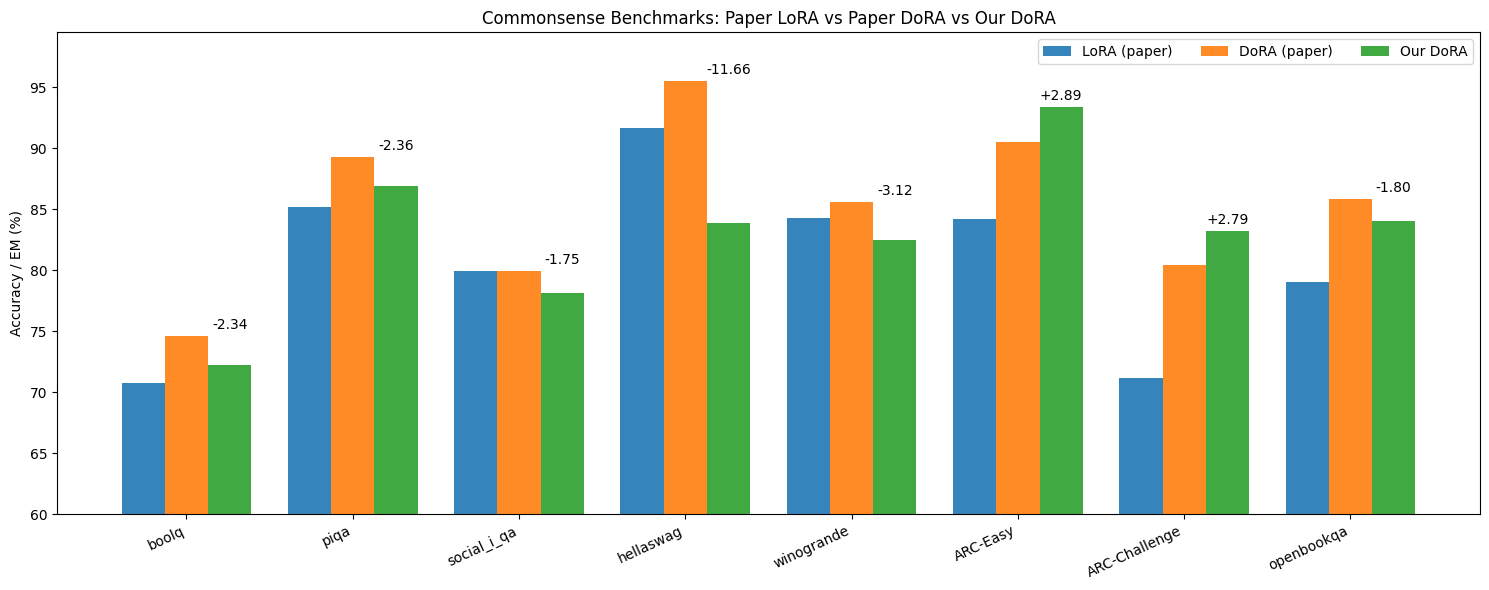

In [ ]:
# 2) Plot 3 sub-bars per task + delta labels
plot_df = df3[df3["Task"] != "Macro Avg"].copy()

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(plot_df))
w = 0.26  # 3 bars => narrower width

b1 = ax.bar(x - w, plot_df["LoRA (paper)"], width=w, label="LoRA (paper)", alpha=0.9)
b2 = ax.bar(x,      plot_df["DoRA (paper)"], width=w, label="DoRA (paper)", alpha=0.9)
b3 = ax.bar(x + w,  plot_df["Our DoRA"], width=w, label="Our DoRA", alpha=0.9)

# Label delta from paper DoRA -> our DoRA above rightmost bar
for i, d in enumerate(plot_df["Δ Our DoRA - Paper DoRA"]):
    ymax = max(
        plot_df["LoRA (paper)"].iloc[i],
        plot_df["DoRA (paper)"].iloc[i],
        plot_df["Our DoRA"].iloc[i],
    )
    ax.text(i + w, ymax + 0.35, f"{d:+.2f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Task"], rotation=25, ha="right")
ax.set_ylabel("Accuracy / EM (%)")
ax.set_title("Commonsense Benchmarks: Paper LoRA vs Paper DoRA vs Our DoRA")
# ax.legend(ncols=3, loc="upper left", bbox_to_anchor=(0, 1.15))
ax.legend(ncols=3, loc="upper right", bbox_to_anchor=(1.0, 1))
ax.set_ylim(60, max(plot_df[["LoRA (paper)", "DoRA (paper)", "Our DoRA"]].max()) + 4)
# ax.set_ylim(50,96)
plt.tight_layout()
plt.show()

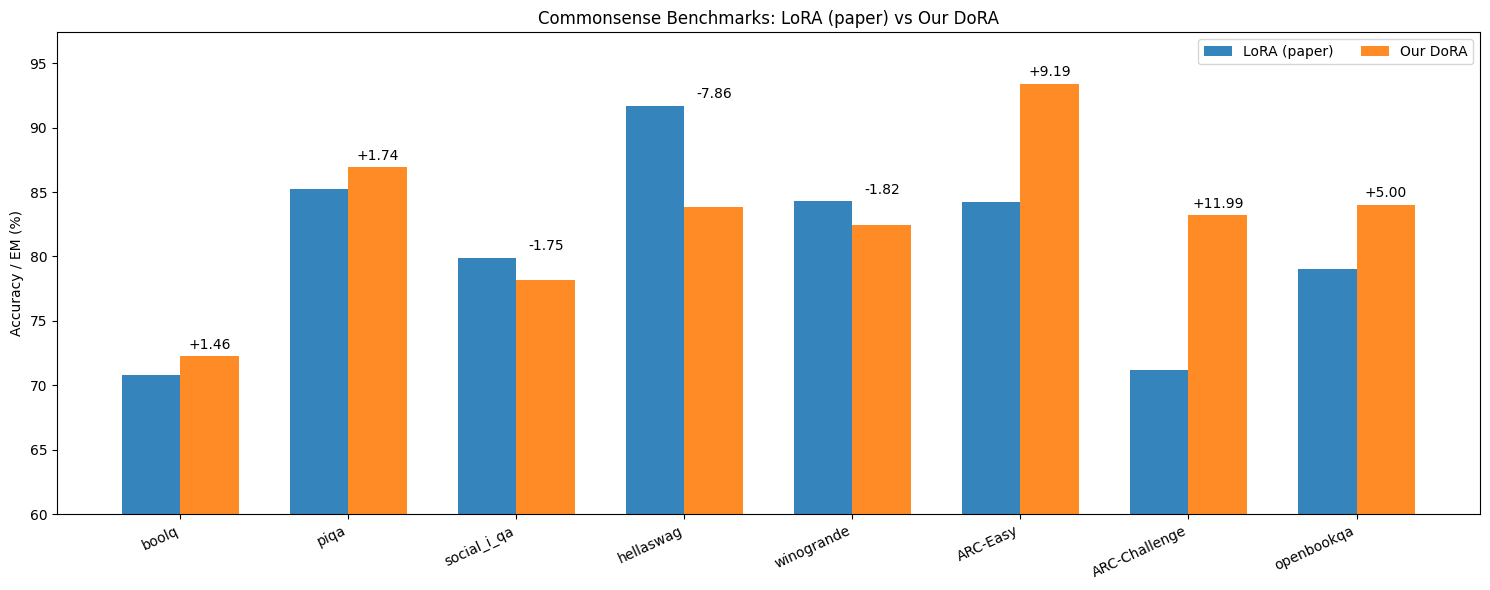

In [ ]:
# Keep only needed columns
plot_df = df3[df3["Task"] != "Macro Avg"].copy()

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(plot_df))
w = 0.35  # wider since only 2 bars

# Bars: LoRA vs Our DoRA
b1 = ax.bar(x - w/2, plot_df["LoRA (paper)"], width=w, label="LoRA (paper)", alpha=0.9)
b2 = ax.bar(x + w/2, plot_df["Our DoRA"], width=w, label="Our DoRA", alpha=0.9)

# Delta labels (Our DoRA - LoRA)
for i, d in enumerate(plot_df["Our DoRA"] - plot_df["LoRA (paper)"]):
    ymax = max(
        plot_df["LoRA (paper)"].iloc[i],
        plot_df["Our DoRA"].iloc[i],
    )
    ax.text(i + w/2, ymax + 0.35, f"{d:+.2f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Task"], rotation=25, ha="right")
ax.set_ylabel("Accuracy / EM (%)")
ax.set_title("Commonsense Benchmarks: LoRA (paper) vs Our DoRA")

ax.legend(ncols=2, loc="upper right", bbox_to_anchor=(1.0, 1))

ax.set_ylim(
    60,
    max(plot_df[["LoRA (paper)", "Our DoRA"]].max()) + 4
)

plt.tight_layout()
plt.show()

###Base Evaluation

In [ ]:
MODEL_ID = "meta-llama/Llama-3.1-8B"

In [ ]:
# @title
# 5b) Eval base model only (no DoRA injection, no adapter checkpoint)
import gc
import re
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from data import format_prompt, load_dataset_json

if "model" in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

print("Loading tokenizer:", MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Loading base model (no adapters):", MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
model.config.use_cache = True
model.eval()

TASKS = ["boolq", "piqa", "social_i_qa", "hellaswag", "winogrande", "ARC-Easy", "ARC-Challenge", "openbookqa"]
TRUE_FALSE = {"TRUE", "FALSE"}
INDEX_TO_LETTER = {str(i): chr(ord("A") + i - 1) for i in range(1, 6)}

def normalize_answer(text):
    answer = str(text).strip().upper()
    answer = re.sub(r"^(ANSWER|RESPONSE)\s*:\s*", "", answer).strip()
    answer = re.sub(r"^(THE\s+)?CORRECT\s+ANSWER\s+IS\s+", "", answer).strip()
    answer = answer.strip(" .,:;\"'`()[]{}")
    indexed = re.search(r"\b(OPTION|ANSWER|ENDING|SOLUTION)\s*([1-5])\b", answer)
    if indexed:
        return INDEX_TO_LETTER[indexed.group(2)]
    if answer in {"YES", "Y"}:
        return "TRUE"
    if answer in {"NO", "N"}:
        return "FALSE"
    if answer.startswith("TRUE"):
        return "TRUE"
    if answer.startswith("FALSE"):
        return "FALSE"
    match = re.search(r"\b([A-E])\b", answer)
    return match.group(1) if match else answer

def gold_for_eval(sample):
    return str(sample["answer"]) if str(sample.get("answer", "")).strip() else str(sample["output"])

def infer_prefix(sample):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    for prefix in ("option", "answer", "ending", "solution"):
        if re.search(rf"\b{prefix}\s*[1-5]\b", text, re.IGNORECASE):
            return prefix
    return None

def num_choices(sample, prefix):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    prefixes = [prefix] if prefix else ["option", "answer", "ending", "solution"]
    max_seen = 0
    for p in prefixes:
        for m in re.finditer(rf"\b{p}\s*([1-5])\b", text, re.IGNORECASE):
            max_seen = max(max_seen, int(m.group(1)))
    return max_seen or 5

def candidate_groups(sample):
    gold_norm = normalize_answer(gold_for_eval(sample))
    if gold_norm in TRUE_FALSE:
        labels = ["true", "false"]
        return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}
    prefix = infer_prefix(sample)
    if prefix:
        labels = [f"{prefix}{i}" for i in range(1, num_choices(sample, prefix) + 1)]
    else:
        labels = [chr(ord("A") + i) for i in range(num_choices(sample, None))]
    return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}

def build_entries(samples, tokenizer, max_prompt_tokens):
    entries = []
    for sample_idx, sample in enumerate(samples):
        prompt_ids = tokenizer(format_prompt(sample), add_special_tokens=True, truncation=False, return_attention_mask=False)["input_ids"]
        if max_prompt_tokens is not None:
            prompt_ids = prompt_ids[-max_prompt_tokens:]
        for label, variants in candidate_groups(sample).items():
            for variant in variants:
                cand_ids = tokenizer(variant, add_special_tokens=False, truncation=False, return_attention_mask=False)["input_ids"]
                if cand_ids:
                    entries.append({"sample_idx": sample_idx, "label": label, "input_ids": prompt_ids + cand_ids, "prompt_len": len(prompt_ids), "candidate_len": len(cand_ids)})
    return entries

@torch.no_grad()
def score_entry_batch(model, entries, pad_token_id):
    device = next(model.parameters()).device
    max_len = max(len(e["input_ids"]) for e in entries)
    input_ids = torch.full((len(entries), max_len), pad_token_id, dtype=torch.long, device=device)
    attention_mask = torch.zeros_like(input_ids)
    for row, e in enumerate(entries):
        ids = torch.tensor(e["input_ids"], dtype=torch.long, device=device)
        input_ids[row, -ids.numel():] = ids
        attention_mask[row, -ids.numel():] = 1
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    logprobs = F.log_softmax(logits, dim=-1)
    out = []
    for row, e in enumerate(entries):
        pad_len = max_len - len(e["input_ids"])
        start = pad_len + e["prompt_len"]
        end = start + e["candidate_len"]
        target = input_ids[row, start:end]
        token_lp = logprobs[row, start - 1:end - 1, :]
        score = token_lp.gather(-1, target.unsqueeze(-1)).squeeze(-1).mean().item()
        out.append((e["sample_idx"], e["label"], score))
    return out

@torch.no_grad()
def evaluate_task_choice(model, tokenizer, samples, batch_size=32, max_prompt_tokens=512, desc="eval"):
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    old_side = getattr(tokenizer, "padding_side", "right")
    tokenizer.padding_side = "left"
    try:
        entries = build_entries(samples, tokenizer, max_prompt_tokens)
        best = [{} for _ in samples]
        for start in tqdm(range(0, len(entries), batch_size), desc=desc, leave=False):
            batch = entries[start:start + batch_size]
            for sample_idx, label, score in score_entry_batch(model, batch, tokenizer.pad_token_id):
                best[sample_idx][label] = max(best[sample_idx].get(label, float("-inf")), score)
        return sum(
            (max(scores, key=scores.get) if scores else "") == normalize_answer(gold_for_eval(sample))
            for sample, scores in zip(samples, best)
        ) / len(samples)
    finally:
        tokenizer.padding_side = old_side

def run_eval(model, tokenizer, eval_dir, n_per_task=200, batch_size=32, max_prompt_tokens=512):
    results = {}
    for task in tqdm(TASKS, desc="tasks"):
        samples = load_dataset_json(Path(eval_dir) / task / "test.json")[:n_per_task]
        acc = evaluate_task_choice(model, tokenizer, samples, batch_size=batch_size, max_prompt_tokens=max_prompt_tokens, desc=task)
        results[task] = round(acc * 100, 2)
        print(f"{task:20s}: {results[task]:6.2f}% ({len(samples)} examples)")
    print("-" * 48)
    print(f"{'Average':20s}: {sum(results.values()) / len(results):6.2f}%")
    return results

base_results = run_eval(model, tokenizer, EVAL_DIR, n_per_task=10**9, batch_size=64, max_prompt_tokens=512)

Loading tokenizer: meta-llama/Llama-3.1-8B
Loading base model (no adapters): meta-llama/Llama-3.1-8B


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

tasks:   0%|          | 0/8 [00:00<?, ?it/s]

boolq:   0%|          | 0/205 [00:00<?, ?it/s]

boolq               :  44.37% (3270 examples)


...

ARC-Easy            :  69.61% (2376 examples)


ARC-Challenge:   0%|          | 0/147 [00:00<?, ?it/s]

ARC-Challenge       :  53.50% (1172 examples)


openbookqa:   0%|          | 0/63 [00:00<?, ?it/s]

openbookqa          :  45.20% (500 examples)
------------------------------------------------
Average             :  50.33%


### Llama3 Base DORA Adapt

In [ ]:
# @title
# 5) Eval cell
# Reloads Instruct base, re-injects custom DoRA, loads adapter_epochN.pt,
# then runs batched multiple-choice likelihood eval with progress bars.

import gc
import re
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from data import format_prompt, load_dataset_json
from inject import inject_dora, print_trainable_params

if "model" in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

ADAPTER_PATH = f"{CKPT_DIR}/adapter_epoch{EPOCHS}_base.pt"
print("Loading adapter:", ADAPTER_PATH)

tokenizer = AutoTokenizer.from_pretrained(CKPT_DIR if Path(CKPT_DIR).is_dir() else MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device_map="cuda")
for p in model.parameters():
    p.requires_grad = False
model = inject_dora(
    model,
    target_names=["q_proj", "k_proj", "v_proj", "o_proj"],
    r=RANK,
    lora_alpha=ALPHA,
    use_llama_mha=True,
    adapt_mlp=ADAPT_MLP,
)
model = model.to(device="cuda", dtype=torch.bfloat16)
print_trainable_params(model)

blob = torch.load(ADAPTER_PATH, map_location="cpu", weights_only=False)
sd = blob["adapter_state_dict"] if isinstance(blob, dict) and "adapter_state_dict" in blob else blob
missing, unexpected = model.load_state_dict(sd, strict=False)
model_keys = dict(model.named_parameters())
matched = sum(k in model_keys for k in sd)
print(f"adapter tensors in ckpt: {len(sd)}")
print(f"matched adapter tensors: {matched}")
print(f"unexpected keys: {len(unexpected)}")
print(f"missing base keys expected: {len(missing)}")
model.eval()

TASKS = ["boolq", "piqa", "social_i_qa", "hellaswag", "winogrande", "ARC-Easy", "ARC-Challenge", "openbookqa"]
TRUE_FALSE = {"TRUE", "FALSE"}
INDEX_TO_LETTER = {str(i): chr(ord("A") + i - 1) for i in range(1, 6)}

def normalize_answer(text):
    answer = str(text).strip().upper()
    answer = re.sub(r"^(ANSWER|RESPONSE)\s*:\s*", "", answer).strip()
    answer = re.sub(r"^(THE\s+)?CORRECT\s+ANSWER\s+IS\s+", "", answer).strip()
    answer = answer.strip(" .,:;\"'`()[]{}")
    indexed = re.search(r"\b(OPTION|ANSWER|ENDING|SOLUTION)\s*([1-5])\b", answer)
    if indexed:
        return INDEX_TO_LETTER[indexed.group(2)]
    if answer in {"YES", "Y"}:
        return "TRUE"
    if answer in {"NO", "N"}:
        return "FALSE"
    if answer.startswith("TRUE"):
        return "TRUE"
    if answer.startswith("FALSE"):
        return "FALSE"
    match = re.search(r"\b([A-E])\b", answer)
    return match.group(1) if match else answer

def gold_for_eval(sample):
    return str(sample["answer"]) if str(sample.get("answer", "")).strip() else str(sample["output"])

def infer_prefix(sample):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    for prefix in ("option", "answer", "ending", "solution"):
        if re.search(rf"\b{prefix}\s*[1-5]\b", text, re.IGNORECASE):
            return prefix
    return None

def num_choices(sample, prefix):
    text = " ".join(str(sample.get(k, "")) for k in ("instruction", "input", "output", "answer"))
    prefixes = [prefix] if prefix else ["option", "answer", "ending", "solution"]
    max_seen = 0
    for p in prefixes:
        for m in re.finditer(rf"\b{p}\s*([1-5])\b", text, re.IGNORECASE):
            max_seen = max(max_seen, int(m.group(1)))
    return max_seen or 5

def candidate_groups(sample):
    gold_norm = normalize_answer(gold_for_eval(sample))
    if gold_norm in TRUE_FALSE:
        labels = ["true", "false"]
        return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}
    prefix = infer_prefix(sample)
    if prefix:
        labels = [f"{prefix}{i}" for i in range(1, num_choices(sample, prefix) + 1)]
    else:
        labels = [chr(ord("A") + i) for i in range(num_choices(sample, None))]
    return {normalize_answer(x): [x, f"the correct answer is {x}"] for x in labels}

def build_entries(samples, tokenizer, max_prompt_tokens):
    entries = []
    for sample_idx, sample in enumerate(samples):
        prompt_ids = tokenizer(format_prompt(sample), add_special_tokens=True, truncation=False, return_attention_mask=False)["input_ids"]
        if max_prompt_tokens is not None:
            prompt_ids = prompt_ids[-max_prompt_tokens:]
        for label, variants in candidate_groups(sample).items():
            for variant in variants:
                cand_ids = tokenizer(variant, add_special_tokens=False, truncation=False, return_attention_mask=False)["input_ids"]
                if cand_ids:
                    entries.append({"sample_idx": sample_idx, "label": label, "input_ids": prompt_ids + cand_ids, "prompt_len": len(prompt_ids), "candidate_len": len(cand_ids)})
    return entries

@torch.no_grad()
def score_entry_batch(model, entries, pad_token_id):
    device = next(model.parameters()).device
    max_len = max(len(e["input_ids"]) for e in entries)
    input_ids = torch.full((len(entries), max_len), pad_token_id, dtype=torch.long, device=device)
    attention_mask = torch.zeros_like(input_ids)
    for row, e in enumerate(entries):
        ids = torch.tensor(e["input_ids"], dtype=torch.long, device=device)
        input_ids[row, -ids.numel():] = ids
        attention_mask[row, -ids.numel():] = 1
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    logprobs = F.log_softmax(logits, dim=-1)
    out = []
    for row, e in enumerate(entries):
        pad_len = max_len - len(e["input_ids"])
        start = pad_len + e["prompt_len"]
        end = start + e["candidate_len"]
        target = input_ids[row, start:end]
        token_lp = logprobs[row, start - 1:end - 1, :]
        score = token_lp.gather(-1, target.unsqueeze(-1)).squeeze(-1).mean().item()
        out.append((e["sample_idx"], e["label"], score))
    return out

@torch.no_grad()
def evaluate_task_choice(model, tokenizer, samples, batch_size=32, max_prompt_tokens=512, desc="eval"):
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    old_side = getattr(tokenizer, "padding_side", "right")
    tokenizer.padding_side = "left"
    try:
        entries = build_entries(samples, tokenizer, max_prompt_tokens)
        best = [{} for _ in samples]
        for start in tqdm(range(0, len(entries), batch_size), desc=desc, leave=False):
            batch = entries[start:start + batch_size]
            for sample_idx, label, score in score_entry_batch(model, batch, tokenizer.pad_token_id):
                best[sample_idx][label] = max(best[sample_idx].get(label, float("-inf")), score)
        return sum(
            (max(scores, key=scores.get) if scores else "") == normalize_answer(gold_for_eval(sample))
            for sample, scores in zip(samples, best)
        ) / len(samples)
    finally:
        tokenizer.padding_side = old_side

def run_eval(model, tokenizer, eval_dir, n_per_task=200, batch_size=32, max_prompt_tokens=512):
    results = {}
    for task in tqdm(TASKS, desc="tasks"):
        samples = load_dataset_json(Path(eval_dir) / task / "test.json")[:n_per_task]
        acc = evaluate_task_choice(model, tokenizer, samples, batch_size=batch_size, max_prompt_tokens=max_prompt_tokens, desc=task)
        results[task] = round(acc * 100, 2)
        print(f"{task:20s}: {results[task]:6.2f}% ({len(samples)} examples)")
    print("-" * 48)
    print(f"{'Average':20s}: {sum(results.values()) / len(results):6.2f}%")
    return results

# Start with subset eval. For full eval, set n_per_task to a very large value.
results = run_eval(model, tokenizer, EVAL_DIR, n_per_task=10**9, batch_size=32, max_prompt_tokens=512)


Loading adapter: /content/drive/MyDrive/DoRA_instruct/checkpoints_custom_instruct/adapter_epoch1_base.pt


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[inject_dora] Replaced 192 layers
  - model.layers.0.self_attn.q_proj
  - model.layers.0.self_attn.k_proj
  - model.layers.0.self_attn.v_proj
  - model.layers.0.self_attn.o_proj
  - model.layers.0.mlp.up_proj
  - model.layers.0.mlp.down_proj
  - model.layers.1.self_attn.q_proj
  - model.layers.1.self_attn.k_proj
  - model.layers.1.self_attn.v_proj
  - model.layers.1.self_attn.o_proj
  - model.layers.1.mlp.up_proj
  - model.layers.1.mlp.down_proj
  - model.layers.2.self_attn.q_proj
  - model.layers.2.self_attn.k_proj
  - model.layers.2.self_attn.v_proj
  - model.layers.2.self_attn.o_proj
  - model.layers.2.mlp.up_proj
  - model.layers.2.mlp.down_proj
  - model.layers.3.self_attn.q_proj
  - model.layers.3.self_attn.k_proj
  ... 172 more
Trainable params: 65,929,216 / 8,096,190,464 (0.8143%) | Frozen: 8,030,261,248


RuntimeError: Error(s) in loading state_dict for LlamaForCausalLM:
	size mismatch for model.layers.0.self_attn.q_proj.magnitude: copying a param with shape torch.Size([4096, 1]) from checkpoint, the shape in current model is torch.Size([4096]).
	size mismatch for model.layers.0.self_attn.k_proj.magnitude: copying a param with shape torch.Size([1024, 1]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for model.layers.0.self_attn.v_proj.magnitude: copying a param with shape torch.Size([1024, 1]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for model.layers.0.self_attn.o_proj.magnitude: copying a param with shape torch.Size([4096, 1]) from checkpoint, the shape in current model is torch.Size([4096]).
	size mismatch for model.layers.0.mlp.up_proj.magnitude: copying a param with shape torch.Size([14336, 1]) from checkpoint, the shape in current model is torch.Size([14336]).
	size mismatch for model.layers.0.mlp.down_pro

In [ ]:
# @title
results_llama31_8b = {
    "Llama-3.1-8B (base)": {
        "boolq": 44.37,
        "piqa": 66.76,
        "social_i_qa": 42.22,
        "hellaswag": 28.73,
        "winogrande": 52.25,
        "ARC-Easy": 69.61,
        "ARC-Challenge": 53.50,
        "openbookqa": 45.20,
        # "Average": 50.33,
    },

    "Llama-3.1-8B (DoRA)": {
        "boolq": 51.83,
        "piqa": 74.91,
        "social_i_qa": 56.42,
        "hellaswag": 45.78,
        "winogrande": 58.34,
        "ARC-Easy": 78.65,
        "ARC-Challenge": 63.82,
        "openbookqa": 57.13,
        # "Average": 60.83,
    },

    "Llama-3.1-8B-Instruct (base)": {
        "boolq": 56.15,
        "piqa": 81.94,
        "social_i_qa": 68.63,
        "hellaswag": 69.00,
        "winogrande": 60.69,
        "ARC-Easy": 92.21,
        "ARC-Challenge": 78.84,
        "openbookqa": 75.60,
        # "Average": 72.88,
    },

    "Llama-3.1-8B-Instruct (DoRA)": {
        "boolq": 72.26,
        "piqa": 86.94,
        "social_i_qa": 78.15,
        "hellaswag": 83.84,
        "winogrande": 82.48,
        "ARC-Easy": 93.39,
        "ARC-Challenge": 83.19,
        "openbookqa": 84.00,
    },



}

In [ ]:
# @title
df_llama31 = pd.DataFrame(results_llama31_8b)

# task names become a column
df_llama31 = df_llama31.reset_index().rename(columns={"index": "Task"})

# improvement columns
# df_llama31["Δ Instruct(base) - Base"] = (
#     df_llama31["Llama-3.1-8B-Instruct (base)"]
#     - df_llama31["Llama-3.1-8B (base)"]
# )

# df_llama31["Δ DoRA - Instruct(base)"] = (
#     df_llama31["Llama-3.1-8B-Instruct (DoRA)"]
#     - df_llama31["Llama-3.1-8B-Instruct (base)"]
# )

# optional macro row
numeric_cols = df_llama31.select_dtypes(include="number").columns

macro_row = {"Task": "Macro Avg"}
for col in numeric_cols:
    macro_row[col] = df_llama31[col].mean()

df_llama31.loc[len(df_llama31)] = macro_row

display(df_llama31)

,Task,Llama-3.1-8B (base),Llama-3.1-8B (DoRA),Llama-3.1-8B-Instruct (base),Llama-3.1-8B-Instruct (DoRA)
0,boolq,44.37,51.83,56.1500,72.26000
1,piqa,66.76,74.91,81.9400,86.94000
2,social_i_qa,42.22,56.42,68.6300,78.15000
3,hellaswag,28.73,45.78,69.0000,83.84000
4,winogrande,52.25,58.34,60.6900,82.48000
5,ARC-Easy,69.61,78.65,92.2100,93.39000
6,ARC-Challenge,53.50,63.82,78.8400,83.19000
7,openbookqa,45.20,57.13,75.6000,84.00000
8,Macro Avg,50.33,60.86,72.8825,83.03125


In [ ]:
# @title
df_llama31 = pd.DataFrame(results_llama31_8b)

# task names become a column
df_llama31 = df_llama31.reset_index().rename(columns={"index": "Task"})

# improvement columns
# df_llama31["Δ Instruct(base) - Base"] = (
#     df_llama31["Llama-3.1-8B-Instruct (base)"]
#     - df_llama31["Llama-3.1-8B (base)"]
# )

# df_llama31["Δ DoRA - Instruct(base)"] = (
#     df_llama31["Llama-3.1-8B-Instruct (DoRA)"]
#     - df_llama31["Llama-3.1-8B-Instruct (base)"]
# )

# optional macro row
numeric_cols = df_llama31.select_dtypes(include="number").columns

macro_row = {"Task": "Macro Avg"}
for col in numeric_cols:
    macro_row[col] = df_llama31[col].mean()

df_llama31.loc[len(df_llama31)] = macro_row

display(df_llama31)

,Task,Llama-3.1-8B (base),Llama-3.1-8B (DoRA),Llama-3.1-8B-Instruct (base),Llama-3.1-8B-Instruct (DoRA)
0,boolq,44.37,51.83,56.1500,72.26000
1,piqa,66.76,74.91,81.9400,86.94000
2,social_i_qa,42.22,56.42,68.6300,78.15000
3,hellaswag,28.73,45.78,69.0000,83.84000
4,winogrande,52.25,58.34,60.6900,82.48000
5,ARC-Easy,69.61,78.65,92.2100,93.39000
6,ARC-Challenge,53.50,63.82,78.8400,83.19000
7,openbookqa,45.20,57.13,75.6000,84.00000
8,Macro Avg,50.33,60.86,72.8825,83.03125
